In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("merged_transactions_feedback.csv")

customer_df = df.groupby("Customer_ID").agg({
    "Transaction_Amount": ["sum", "mean"],
    "Satisfaction_Score": "mean",
    "Likelihood_to_Recommend": "mean",
    "Transaction_ID": "count"
}).reset_index()

customer_df.columns = [
    "Customer_ID",
    "Total_Transaction_Amount",
    "Avg_Transaction_Amount",
    "Avg_Satisfaction_Score",
    "Avg_Likelihood_to_Recommend",
    "Transaction_Count"
]

customer_df["Log_Total_Transaction_Amount"] = np.log1p(customer_df["Total_Transaction_Amount"])
customer_df["Income_Level_Group"] = pd.qcut(
    customer_df["Total_Transaction_Amount"],
    q=3,
    labels=["Low", "Middle", "High"]
)
customer_df.head()

,Customer_ID,Total_Transaction_Amount,Avg_Transaction_Amount,Avg_Satisfaction_Score,Avg_Likelihood_to_Recommend,Transaction_Count,Log_Total_Transaction_Amount,Income_Level_Group
0,1,33672.0,2806.0,8.500000,9.000000,12,10.424452,Low
1,2,14721.0,2453.5,4.333333,5.000000,6,9.597098,Low
2,3,4614.0,1538.0,8.333333,3.666667,3,8.437067,Low
3,4,49770.0,4147.5,5.500000,3.333333,12,10.815188,Middle
4,5,133182.0,2959.6,6.444444,5.666667,45,11.799479,High


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "Log_Total_Transaction_Amount",
    "Avg_Transaction_Amount",
    "Avg_Satisfaction_Score",
    "Avg_Likelihood_to_Recommend",
    "Transaction_Count"
]

X = customer_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

pd.crosstab(customer_df["Cluster"], customer_df["Income_Level_Group"])

Income_Level_Group,Low,Middle,High
Cluster,,,
0,331,251,12
1,0,80,313
2,0,0,6


In [5]:
cluster_profile_median = customer_df.groupby("Cluster").agg({
    "Log_Total_Transaction_Amount": "median",
    "Avg_Transaction_Amount": "median",
    "Transaction_Count": "median",
    "Avg_Satisfaction_Score": "median",
    "Avg_Likelihood_to_Recommend": "median"
}).round(2)

cluster_profile_median["Cluster_Size"] = customer_df["Cluster"].value_counts().sort_index()

cluster_profile_median

,Log_Total_Transaction_Amount,Avg_Transaction_Amount,Transaction_Count,Avg_Satisfaction_Score,Avg_Likelihood_to_Recommend,Cluster_Size
Cluster,,,,,,
0,10.46,2375.04,15.0,5.57,5.75,594
1,11.42,2541.20,36.0,5.62,5.40,393
2,14.40,77515.95,22.5,5.96,6.38,6


In [6]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil_score = silhouette_score(X_scaled, customer_df["Cluster"])
ch_score = calinski_harabasz_score(X_scaled, customer_df["Cluster"])

print("Silhouette Score:", round(sil_score, 4))
print("Calinski-Harabasz Score:", round(ch_score, 4))

Silhouette Score: 0.2617
Calinski-Harabasz Score: 325.8808


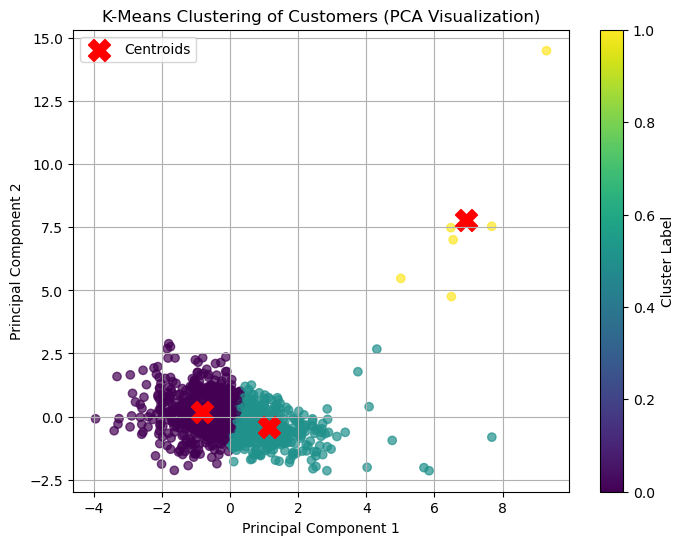

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

customer_df["PC1"] = X_pca[:, 0]
customer_df["PC2"] = X_pca[:, 1]

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(
    customer_df["PC1"],
    customer_df["PC2"],
    c=customer_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Customers (PCA Visualization)")
plt.colorbar(label="Cluster Label")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

pca_loadings

,PC1,PC2
Log_Total_Transaction_Amount,0.705181,0.012387
Avg_Transaction_Amount,0.326649,0.617976
Avg_Satisfaction_Score,-0.003845,0.191972
Avg_Likelihood_to_Recommend,-0.030359,0.700773
Transaction_Count,0.628557,-0.300027


In [9]:
print("Top 2 features for PC1:")
print(pca_loadings["PC1"].abs().sort_values(ascending=False).head(2))

print("\nTop 2 features for PC2:")
print(pca_loadings["PC2"].abs().sort_values(ascending=False).head(2))

Top 2 features for PC1:
Log_Total_Transaction_Amount    0.705181
Transaction_Count               0.628557
Name: PC1, dtype: float64

Top 2 features for PC2:
Avg_Likelihood_to_Recommend    0.700773
Avg_Transaction_Amount         0.617976
Name: PC2, dtype: float64


In [10]:
variables = [
    "Log_Total_Transaction_Amount",
    "Avg_Transaction_Amount",
    "Transaction_Count",
    "Avg_Satisfaction_Score",
    "Avg_Likelihood_to_Recommend"
]

In [11]:
from scipy.stats import f_oneway

cluster0 = customer_df[customer_df["Cluster"] == 0]
cluster1 = customer_df[customer_df["Cluster"] == 1]
cluster2 = customer_df[customer_df["Cluster"] == 2]

variables = [
    "Log_Total_Transaction_Amount",
    "Avg_Transaction_Amount",
    "Transaction_Count",
    "Avg_Satisfaction_Score",
    "Avg_Likelihood_to_Recommend"
]

anova_results = []

for var in variables:
    f_stat, p_value = f_oneway(cluster0[var], cluster1[var], cluster2[var])
    anova_results.append({
        "Variable": var,
        "F-Statistic": round(f_stat, 2),
        "P-Value": p_value
    })

anova_df = pd.DataFrame(anova_results)
anova_df

,Variable,F-Statistic,P-Value
0,Log_Total_Transaction_Amount,669.96,1.013768e-184
1,Avg_Transaction_Amount,2358.23,0.000000e+00
2,Transaction_Count,633.07,8.361630e-178
3,Avg_Satisfaction_Score,0.22,8.050163e-01
4,Avg_Likelihood_to_Recommend,10.98,1.917835e-05
